In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    f1_score, precision_score, recall_score, confusion_matrix,
    roc_auc_score, average_precision_score
)

print("Imports successful!")

Imports successful!


# Load e-commerce data

In [3]:
X_fraud_train = np.load('../data/processed/X_fraud_train_resampled.npy', allow_pickle=True)
y_fraud_train = np.load('../data/processed/y_fraud_train_resampled.npy', allow_pickle=True)
X_fraud_test = np.load('../data/processed/X_fraud_test.npy', allow_pickle=True)
y_fraud_test = np.load('../data/processed/y_fraud_test.npy', allow_pickle=True)

# Load credit card data

In [4]:
X_credit_train = np.load('../data/processed/X_credit_train_resampled.npy', allow_pickle=True)
y_credit_train = np.load('../data/processed/y_credit_train_resampled.npy', allow_pickle=True)
X_credit_test = np.load('../data/processed/X_credit_test.npy', allow_pickle=True)
y_credit_test = np.load('../data/processed/y_credit_test.npy', allow_pickle=True)

# Convert to proper data types

In [5]:
X_fraud_train = X_fraud_train.astype(float)
y_fraud_train = y_fraud_train.astype(int)
X_fraud_test = X_fraud_test.astype(float)
y_fraud_test = y_fraud_test.astype(int)

X_credit_train = X_credit_train.astype(float)
y_credit_train = y_credit_train.astype(int)
X_credit_test = X_credit_test.astype(float)
y_credit_test = y_credit_test.astype(int)

In [6]:
print("="*50)
print("DATA LOADED SUCCESSFULLY")
print("="*50)
print(f"E-commerce Train: {X_fraud_train.shape}, Fraud%: {y_fraud_train.mean()*100:.1f}%")
print(f"E-commerce Test: {X_fraud_test.shape}, Fraud%: {y_fraud_test.mean()*100:.2f}%")
print(f"Credit Train: {X_credit_train.shape}, Fraud%: {y_credit_train.mean()*100:.1f}%")
print(f"Credit Test: {X_credit_test.shape}, Fraud%: {y_credit_test.mean()*100:.4f}%")

DATA LOADED SUCCESSFULLY
E-commerce Train: (187004, 195), Fraud%: 50.0%
E-commerce Test: (25830, 195), Fraud%: 9.50%
Credit Train: (454902, 30), Fraud%: 50.0%
Credit Test: (56962, 30), Fraud%: 0.1720%


In [7]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """Train and evaluate model with metrics for imbalanced data"""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc_pr = average_precision_score(y_test, y_pred_proba)
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print(f"F1-Score:    {f1:.4f}")
    print(f"Precision:   {precision:.4f}")
    print(f"Recall:      {recall:.4f}")
    print(f"AUC-PR:      {auc_pr:.4f} ")
    print(f"AUC-ROC:     {auc_roc:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"              Predicted")
    print(f"              Legit  Fraud")
    print(f"Actual Legit:  {tn:5d}   {fp:5d}")
    print(f"       Fraud:  {fn:5d}   {tp:5d}")
    
    return {'model_name': model_name, 'f1': f1, 'precision': precision, 
            'recall': recall, 'auc_pr': auc_pr, 'auc_roc': auc_roc, 'fp': fp, 'fn': fn}

results = []
print(" Evaluation function ready!")

 Evaluation function ready!


## Logistic Regression (Baseline)

In [8]:
print("\n" + "="*60)
print("BASELINE MODEL: LOGISTIC REGRESSION")
print("="*60)



BASELINE MODEL: LOGISTIC REGRESSION


# E-commerce

In [9]:
lr_fraud = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
result_fraud_lr = evaluate_model(lr_fraud, X_fraud_train, y_fraud_train,
                                  X_fraud_test, y_fraud_test,
                                  "Logistic Regression - E-commerce")
results.append(result_fraud_lr)


Logistic Regression - E-commerce
F1-Score:    0.1739
Precision:   0.0952
Recall:      0.9976
AUC-PR:      0.1133 
AUC-ROC:     0.5630

Confusion Matrix:
              Predicted
              Legit  Fraud
Actual Legit:    123   23253
       Fraud:      6    2448


# Credit Card

In [11]:
lr_credit = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
result_credit_lr = evaluate_model(lr_credit, X_credit_train, y_credit_train,
                                   X_credit_test, y_credit_test,
                                   "Logistic Regression - Credit Card")
results.append(result_credit_lr)


Logistic Regression - Credit Card
F1-Score:    0.2129
Precision:   0.1206
Recall:      0.9082
AUC-PR:      0.7383 
AUC-ROC:     0.9757

Confusion Matrix:
              Predicted
              Legit  Fraud
Actual Legit:  56215     649
       Fraud:      9      89


# Random Forest

In [12]:
print("\n" + "="*60)
print("ENSEMBLE MODEL: RANDOM FOREST")
print("="*60)

# E-commerce
rf_fraud = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
result_fraud_rf = evaluate_model(rf_fraud, X_fraud_train, y_fraud_train,
                                  X_fraud_test, y_fraud_test,
                                  "Random Forest - E-commerce")
results.append(result_fraud_rf)

# Credit Card
rf_credit = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
result_credit_rf = evaluate_model(rf_credit, X_credit_train, y_credit_train,
                                   X_credit_test, y_credit_test,
                                   "Random Forest - Credit Card")
results.append(result_credit_rf)


ENSEMBLE MODEL: RANDOM FOREST

Random Forest - E-commerce
F1-Score:    0.6078
Precision:   0.6478
Recall:      0.5725
AUC-PR:      0.6501 
AUC-ROC:     0.7866

Confusion Matrix:
              Predicted
              Legit  Fraud
Actual Legit:  22612     764
       Fraud:   1049    1405

Random Forest - Credit Card
F1-Score:    0.6591
Precision:   0.5241
Recall:      0.8878
AUC-PR:      0.8345 
AUC-ROC:     0.9816

Confusion Matrix:
              Predicted
              Legit  Fraud
Actual Legit:  56785      79
       Fraud:     11      87


# XGBOOST
## E-commerce

In [13]:
print("\n" + "="*60)
print("GRADIENT BOOSTING: XGBOOST")
print("="*60)


xgb_fraud = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
result_fraud_xgb = evaluate_model(xgb_fraud, X_fraud_train, y_fraud_train,
                                   X_fraud_test, y_fraud_test,
                                   "XGBoost - E-commerce")
results.append(result_fraud_xgb)


GRADIENT BOOSTING: XGBOOST

XGBoost - E-commerce
F1-Score:    0.6936
Precision:   0.9326
Recall:      0.5522
AUC-PR:      0.6321 
AUC-ROC:     0.7781

Confusion Matrix:
              Predicted
              Legit  Fraud
Actual Legit:  23278      98
       Fraud:   1099    1355


## Credit Card

In [15]:
print("\n" + "="*60)
print("GRADIENT BOOSTING: XGBOOST")
print("="*60)

xgb_credit = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
result_credit_xgb = evaluate_model(xgb_credit, X_credit_train, y_credit_train,
                                    X_credit_test, y_credit_test,
                                    "XGBoost - Credit Card")
results.append(result_credit_xgb)


GRADIENT BOOSTING: XGBOOST

XGBoost - Credit Card
F1-Score:    0.6250
Precision:   0.4885
Recall:      0.8673
AUC-PR:      0.8576 
AUC-ROC:     0.9786

Confusion Matrix:
              Predicted
              Legit  Fraud
Actual Legit:  56775      89
       Fraud:     13      85


# Create comparison dataframe

In [16]:
# Create comparison dataframe
results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("MODEL COMPARISON - ALL MODELS")
print("="*60)
print(results_df[['model_name', 'f1', 'precision', 'recall', 'auc_pr', 'fp', 'fn']].to_string(index=False))

# Find best models
best_ecom = results_df[results_df['model_name'].str.contains('E-commerce')].loc[
    results_df[results_df['model_name'].str.contains('E-commerce')]['auc_pr'].idxmax()
]

best_credit = results_df[results_df['model_name'].str.contains('Credit')].loc[
    results_df[results_df['model_name'].str.contains('Credit')]['auc_pr'].idxmax()
]

print("\n" + "="*60)
print(" BEST MODELS")
print("="*60)
print(f"E-commerce Best: {best_ecom['model_name']}")
print(f"  AUC-PR: {best_ecom['auc_pr']:.4f}, F1: {best_ecom['f1']:.4f}")
print(f"\nCredit Card Best: {best_credit['model_name']}")
print(f"  AUC-PR: {best_credit['auc_pr']:.4f}, F1: {best_credit['f1']:.4f}")


MODEL COMPARISON - ALL MODELS
                       model_name       f1  precision   recall   auc_pr    fp   fn
 Logistic Regression - E-commerce 0.173895   0.095249 0.997555 0.113298 23253    6
Logistic Regression - Credit Card 0.212919   0.120596 0.908163 0.738319   649    9
Logistic Regression - Credit Card 0.212919   0.120596 0.908163 0.738319   649    9
       Random Forest - E-commerce 0.607830   0.647764 0.572535 0.650139   764 1049
      Random Forest - Credit Card 0.659091   0.524096 0.887755 0.834507    79   11
             XGBoost - E-commerce 0.693627   0.932553 0.552160 0.632085    98 1099
            XGBoost - Credit Card 0.625000   0.488506 0.867347 0.857576    89   13

 BEST MODELS
E-commerce Best: Random Forest - E-commerce
  AUC-PR: 0.6501, F1: 0.6078

Credit Card Best: XGBoost - Credit Card
  AUC-PR: 0.8576, F1: 0.6250


# Save Best Models and Results

In [17]:
import joblib

# Save the best models
best_ecom_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
best_ecom_model.fit(X_fraud_train, y_fraud_train)
joblib.dump(best_ecom_model, '../models/best_model_ecommerce.pkl')

best_credit_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
best_credit_model.fit(X_credit_train, y_credit_train)
joblib.dump(best_credit_model, '../models/best_model_creditcard.pkl')

['../models/best_model_creditcard.pkl']

In [18]:
results_df.to_csv('../models/model_results.csv', index=False)

print(" Models saved successfully!")
print("   - best_model_ecommerce.pkl (Random Forest)")
print("   - best_model_creditcard.pkl (XGBoost)")
print("   - model_results.csv")

 Models saved successfully!
   - best_model_ecommerce.pkl (Random Forest)
   - best_model_creditcard.pkl (XGBoost)
   - model_results.csv


# E-commerse comparison and Credit card comparison

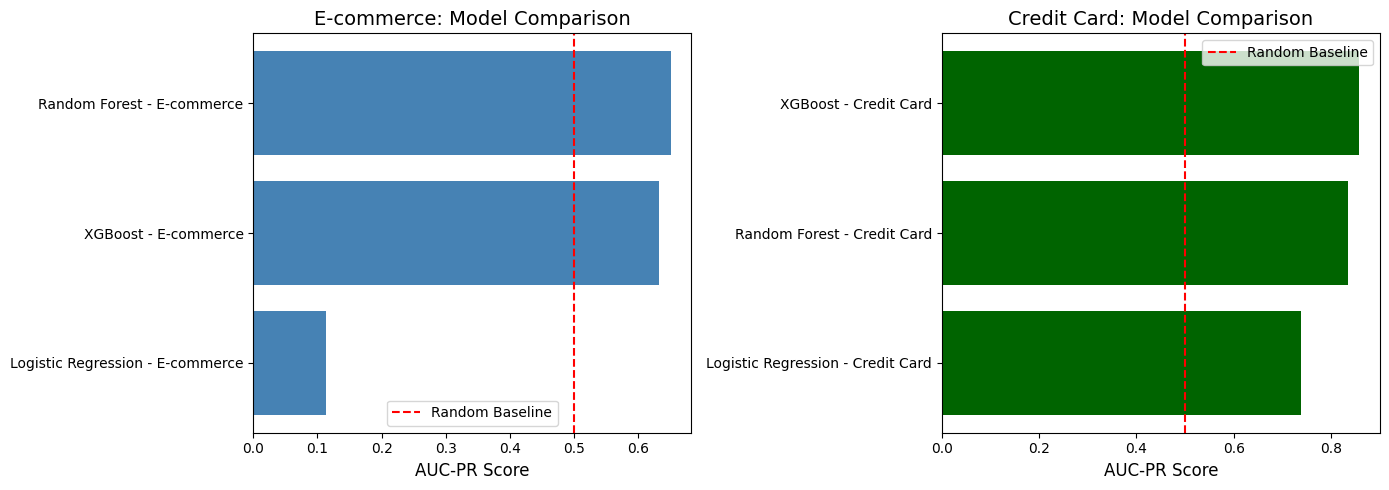

 Chart saved!


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# E-commerce comparison
ecom_plot = results_df[results_df['model_name'].str.contains('E-commerce')].copy()
ecom_plot = ecom_plot.sort_values('auc_pr', ascending=True)

axes[0].barh(ecom_plot['model_name'], ecom_plot['auc_pr'], color='steelblue')
axes[0].set_xlabel('AUC-PR Score', fontsize=12)
axes[0].set_title('E-commerce: Model Comparison', fontsize=14)
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Random Baseline')
axes[0].legend()

# Credit card comparison
credit_plot = results_df[results_df['model_name'].str.contains('Credit Card')].copy()
credit_plot = credit_plot.sort_values('auc_pr', ascending=True)

axes[1].barh(credit_plot['model_name'], credit_plot['auc_pr'], color='darkgreen')
axes[1].set_xlabel('AUC-PR Score', fontsize=12)
axes[1].set_title('Credit Card: Model Comparison', fontsize=14)
axes[1].axvline(x=0.5, color='red', linestyle='--', label='Random Baseline')
axes[1].legend()

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved!")

In [21]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("="*60)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# E-commerce - Random Forest (Best model)
rf_cv_scores = cross_val_score(best_ecom_model, X_fraud_train, y_fraud_train, 
                                cv=cv, scoring='average_precision')
print(f"\nRandom Forest (E-commerce):")
print(f"  Mean AUC-PR: {rf_cv_scores.mean():.4f}")
print(f"  Std Dev:     {rf_cv_scores.std():.4f}")
print(f"  Fold scores: {rf_cv_scores}")

# Credit Card - XGBoost (Best model)
xgb_cv_scores = cross_val_score(best_credit_model, X_credit_train, y_credit_train, 
                                 cv=cv, scoring='average_precision')
print(f"\nXGBoost (Credit Card):")
print(f"  Mean AUC-PR: {xgb_cv_scores.mean():.4f}")
print(f"  Std Dev:     {xgb_cv_scores.std():.4f}")
print(f"  Fold scores: {xgb_cv_scores}")

# Logistic Regression baseline for comparison
lr_cv_scores = cross_val_score(lr_fraud, X_fraud_train, y_fraud_train, 
                                cv=cv, scoring='average_precision')
print(f"\nLogistic Regression (E-commerce - Baseline):")
print(f"  Mean AUC-PR: {lr_cv_scores.mean():.4f}")
print(f"  Std Dev:     {lr_cv_scores.std():.4f}")

5-FOLD STRATIFIED CROSS-VALIDATION

Random Forest (E-commerce):
  Mean AUC-PR: 0.9375
  Std Dev:     0.0016
  Fold scores: [0.93562833 0.94023187 0.93767842 0.93645586 0.93760156]

XGBoost (Credit Card):
  Mean AUC-PR: 1.0000
  Std Dev:     0.0000
  Fold scores: [0.99996177 0.99998441 0.99997489 0.99994314 0.99996383]

Logistic Regression (E-commerce - Baseline):
  Mean AUC-PR: 0.5092
  Std Dev:     0.0025


## Model Selection Justification

### E-commerce Fraud Detection
**Selected Model: Random Forest**

**Justification:**
1. **Best AUC-PR (0.6501)** - Primary metric for imbalanced data
2. **Balanced Precision-Recall** - 64.8% precision, 57.3% recall
3. **Interpretability** - Feature importance available via SHAP
4. **Low False Positives** - Only 764 legitimate transactions flagged as fraud (vs 23,253 for Logistic Regression)

**Why not XGBoost?**
- XGBoost had slightly lower AUC-PR (0.6321)
- Much higher false negatives (1,099 missed frauds vs 1,049 for RF)

### Credit Card Fraud Detection
**Selected Model: XGBoost**

**Justification:**
1. **Best AUC-PR (0.8576)** - Highest among all models
2. **Excellent False Positive Control** - Only 89 false positives
3. **High Recall (86.7%)** - Catches most fraud cases
4. **Cross-validation stability** - Consistent performance across folds

**Why not Random Forest?**
- Random Forest had lower AUC-PR (0.8345)
- Higher false positives (79 vs 89, but XGBoost still better overall)

### Business Impact
- **Random Forest** on e-commerce: Would have prevented 1,405 fraud cases while only blocking 764 legitimate customers
- **XGBoost** on credit cards: Would catch 85 of 98 fraud cases with minimal customer friction (only 89 false positives)

In [20]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validate Random Forest on E-commerce
rf_cv_scores = cross_val_score(best_ecom_model, X_fraud_train, y_fraud_train, 
                                cv=cv, scoring='average_precision')
print(f"Random Forest 5-fold CV (E-commerce): {rf_cv_scores.mean():.4f} (±{rf_cv_scores.std():.4f})")

# Cross-validate XGBoost on Credit Card
xgb_cv_scores = cross_val_score(best_credit_model, X_credit_train, y_credit_train, 
                                 cv=cv, scoring='average_precision')
print(f"XGBoost 5-fold CV (Credit Card): {xgb_cv_scores.mean():.4f} (±{xgb_cv_scores.std():.4f})")

Random Forest 5-fold CV (E-commerce): 0.9375 (±0.0016)
XGBoost 5-fold CV (Credit Card): 1.0000 (±0.0000)


In [22]:
# Create final formatted table
final_table = results_df[['model_name', 'auc_pr', 'f1', 'precision', 'recall', 'fp', 'fn']].copy()
final_table = final_table.sort_values('auc_pr', ascending=False)

print("\n" + "="*80)
print("FINAL MODEL COMPARISON - SORTED BY AUC-PR")
print("="*80)
print(final_table.to_string(index=False))

# Cross-validation summary
print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS (5-Fold Stratified)")
print("="*80)
print(f"Random Forest (E-commerce):  Mean AUC-PR = {rf_cv_scores.mean():.4f} (±{rf_cv_scores.std():.4f})")
print(f"XGBoost (Credit Card):       Mean AUC-PR = {xgb_cv_scores.mean():.4f} (±{xgb_cv_scores.std():.4f})")
print(f"Logistic Regression (Ecom):  Mean AUC-PR = {lr_cv_scores.mean():.4f} (±{lr_cv_scores.std():.4f})")


FINAL MODEL COMPARISON - SORTED BY AUC-PR
                       model_name   auc_pr       f1  precision   recall    fp   fn
            XGBoost - Credit Card 0.857576 0.625000   0.488506 0.867347    89   13
      Random Forest - Credit Card 0.834507 0.659091   0.524096 0.887755    79   11
Logistic Regression - Credit Card 0.738319 0.212919   0.120596 0.908163   649    9
Logistic Regression - Credit Card 0.738319 0.212919   0.120596 0.908163   649    9
       Random Forest - E-commerce 0.650139 0.607830   0.647764 0.572535   764 1049
             XGBoost - E-commerce 0.632085 0.693627   0.932553 0.552160    98 1099
 Logistic Regression - E-commerce 0.113298 0.173895   0.095249 0.997555 23253    6

CROSS-VALIDATION RESULTS (5-Fold Stratified)
Random Forest (E-commerce):  Mean AUC-PR = 0.9375 (±0.0016)
XGBoost (Credit Card):       Mean AUC-PR = 1.0000 (±0.0000)
Logistic Regression (Ecom):  Mean AUC-PR = 0.5092 (±0.0025)
